## Fit the SED of V455 Aur

In [1]:
# pylint: disable=invalid-name, no-member, missing-function-docstring, wildcard-import, line-too-long
from pathlib import Path
import warnings
import numpy as np

# pylint: disable=unnecessary-pass
%matplotlib widget
import matplotlib.pyplot as plt
import corner

# pylint: disable=wrong-import-position
warnings.filterwarnings("ignore", "Using UFloat objects with std_dev==0 may give unexpected results.", category=UserWarning)
from uncertainties import ufloat, nominal_value as nom_val
from uncertainties.unumpy import nominal_values as nom_vals
import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation
from astropy.time import Time

from dust_extinction.parameter_averages import G23

from deblib.vmath import wrap_func_for_uncertainties

from support.extinction import get_gontcharov_av
from support.sed import get_sed_for_target, retain_only_closest_observations
from support.plots import plot_sed, plot_fitted_model
from support.pipeline import deredden, dist_by_brightness_and_teff

from sed_fit.fitter import create_theta, model_func, minimize_fit, mcmc_fit
from sed_fit.generic_fitter import samples_from_sampler
from sed_fit.stellar_grids import get_stellar_grid

Define the target details. In this case it is V455 Aur

In [ ]:
use_quick_mode = True
fit_av = True
NUM_STARS = 3

target_config = {
    "target": "V455 Aur",
    "search_term": "TIC 470966839",
    "source": "Southworth (2021Obs...141..190S) Rediscussion 5, Tables II & III.",
    "citation_key": "Southworth21obsR5",

    # From Table I
    "aka": "TIC 470966839, HD 45191",
    "gaia_dr3_id": 992435451683384320,
    "spt": "F5 V + F6 V",

    # Mags from SIMBAD
    "mags": {
        "B": ufloat(7.71, 0.01, "mag(B)"),          # Tycho (2009A&A...500..583H)
        "V": ufloat(7.23, 0.01, "mag(V)"),          # Tycho (2009A&A...500..583H)
        "G": ufloat(7.146340, 0.002773, "mag(G)"),  # Gaia EDR3 (2020yCat.1350....0G)
        "J": ufloat(6.353, 0.019, "mag(J)"),        # 2MASS (2003yCat.2246....0C)
        "H": ufloat(6.132, 0.038, "mag(H)"),        # 2MASS (2003yCat.2246....0C)
        "K": ufloat(6.082, 0.024, "mag(K)"),        # 2MASS (2003yCat.2246....0C)
        "obs_time_2mass": Time(2451467.9732, format="jd", scale="utc", location=EarthLocation.of_site("ctio"))
    },

    # From Gaia DR3
    "ra": 97.22825356291291,                                        # deg
    "dec": 52.12573403434712,                                       # deg
    "parallax": ufloat(12.873868466441877, 0.05172814056277275),    # mas
    "ruwe": 2.3356,                                                 # Not reliable (>1.4)

    # From TIC
    "Teff_sys": ufloat(6406.0, 141.7),
    "logg_sys": ufloat(3.9344, 0.0918),

    # From Table II
    "k": ufloat(0.949, 0.017),
    "J": ufloat(0.9543, 0.0011),
    "L2": ufloat(0.0282, 0.0022),
    "LR": ufloat(0.859, 0.031),
    "rA": ufloat(0.1130, 0.0009),
    "rB": ufloat(0.1072, 0.0011),
    "t0": ufloat(2458853.778650, 0.000008),         # BJD_TDB
    "period": ufloat(3.145777, 0.000004),           # d

    # From Table V
    "a": ufloat(12.295, 0.017),                     # solRad
    "MA": ufloat(1.289, 0.006),                     # solMass
    "MB": ufloat(1.232, 0.005),                     # solMass
    "RA": ufloat(1.389, 0.011),                     # solRad
    "RB": ufloat(1.318, 0.014),                     # solRad
    "TeffA": ufloat(6500, 200),                     # K
    "TeffB": ufloat(6400, 200),                     # K
    "loggA": ufloat(4.2626, 0.0070),                # cgs
    "loggB": ufloat(4.2887, 0.0089),                # cgs
    "Av": ufloat(0.002, 0.002) * 3.1,
    "TeffR": ufloat(6400, 200) / ufloat(6500, 200),

    # Putative K dwarf third component (we'll generate ratios off of these)
    "MC": ufloat(0.5, 0.2),                         # solMass
    "RC": ufloat(0.8, 0.2),                         # solRad
    "TeffC": ufloat(4500, 500),                     # K
    "loggC": ufloat(4.5, 0.1),                      # cgs
    
    "k2": ufloat(0.58, 0.1),                        # ~ 0.8 R_sun / 1.389 R_sun
    "TeffR2": ufloat(0.7, 0.1),                     # ~ 4500 K / 6500 K
    "loggR2": ufloat(1.05, 0.1)                     # ~ 4.5 / 4.2626
}

if "dist" not in target_config and "parallax" in target_config:
    target_config["dist"] = 1000 / target_config["parallax"]

In [74]:
subs = ["ABCDEFG"[k] for k in range(NUM_STARS)]
theta_plot_labels = np.array([f"$T_{{\\rm eff,{sub}}} / {{\\rm K}}$" for sub in subs] \
                            +[f"$\\log{{g}}_{{\\rm {sub}}}$" for sub in subs] \
                            +[f"$R_{{\\rm {sub}}} / {{\\rm R_{{\\odot}}}}$" for sub in subs] \
                            +["${\\rm dist} / {\\rm pc}$", "${\\rm A_{V}}$"])

theta_keys = np.array([(f"Teff{sub}", u.K) for sub in subs] \
                    + [(f"logg{sub}", u.dex) for sub in subs] \
                    + [(f"R{sub}", u.Rsun) for sub in subs] \
                    + [("dist", u.pc), ("Av", u.dimensionless_unscaled)])

### Fill in any gaps from catalogue lookup

In [75]:
coords = SkyCoord(ra=target_config["ra"] * u.deg, dec=target_config["dec"] * u.deg,
                  distance=nom_val(target_config["dist"]) * u.pc, frame="icrs")
print(f"\n{target_config['target']} SkyCoords are {coords} (or {coords.to_string('hmsdms')})")


V455 Aur SkyCoords are <SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    (97.22825356, 52.12573403, 77.67672962)> (or 06h28m54.7808551s +52d07m32.64252365s)


### Chose the extinction curve and set up the synthetic model grid
The G23 (Gordon et al., 2023) Milky Way R(V) filter gives us the broadest coverage.

There are BtSettlGrid and KuruczGrid stellar grids available, but the former has broader coverage.

In [5]:
ext_model = G23(Rv=3.1)
model_grid = get_stellar_grid("BtSettlGrid", extinction_model=ext_model,
                              use_quick_mode=use_quick_mode, verbose=True)

Loading model grid from bt-settl-agss.npz created at 2026-07-25 17:56:37.104721+00:00
BtSettlGrid is initializing the fluxes interpolator with a grid of 112 teff, 6 logg & 4 metal values and 5000 wavelength bins...will use slinear interpolation...done.
The use of quick mode requested so will set up pre-filtered fluxes.
Initializing pre-filtered fluxes for 38 filters......................................done.


### Get the SED
The initial call the `get_sed_for_target()` will query the
[VizieR Photometry service](https://vizier.cds.unistra.fr/vizier/sed/doc/). This aggregates and returns
photometric observations from across the platform's many catalogues within a chosen radius of the target.
Once received, the table is pre-processed to ensure consistent units, apply default uncertainties where
missing and to remove duplicate rows.

The call to `retain_only_closest_observations()` then removes all but one observation per filter,
with the closes to the target's coordinates being retained.

Finally, the table is further restricted to remove observations with filters not supported by
the stellar model or any that have been explicitly listed for exclusion.

In [76]:
sed = get_sed_for_target(target_config["target"], target_config["search_term"],
                         radius=0.25, remove_duplicates=True, verbose=True)
sed = retain_only_closest_observations(sed, coords)

# Exclusions for range and filters (either unknown or known & problematic)
model_mask = np.ones((len(sed)), dtype=bool)
model_mask &= model_grid.has_filter(sed["sed_filter"])
model_mask &= np.isin(sed["_tabname"], ["J/ApJS/235/6/catalog"], invert="True")
model_mask &= np.isin(sed["sed_filter"], [], invert=True)
model_mask &= (sed["sed_wl"] >= min(model_grid.wavelength_range)) \
            & (sed["sed_wl"] <= max(model_grid.wavelength_range))
sed = sed[model_mask]

print(f"{len(sed)} unique SED observation(s) retained after range & exclusion filtering,",
      "\nand the selection of the 'closest' observation to the target for each Filter.",
      "\nThe units for flux, frequency and wavelength are:",
      ", ".join(f"{sed[f].unit:unicode}" for f in ["sed_flux", "sed_freq", "sed_wl"]))

Opened SED table v455-aur-0.25.vot containing 117 row(s).
Dropped 28 duplicate(s) leaving 89 unique row(s).
16 unique SED observation(s) retained after range & exclusion filtering, 
and the selection of the 'closest' observation to the target for each Filter. 
The units for flux, frequency and wavelength are: W Hz⁻¹ m⁻², Hz, µm


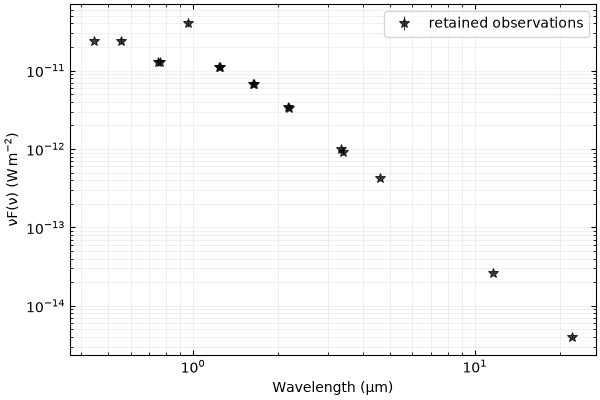

In [77]:
plt.show(plot_sed(x=sed["sed_wl"].quantity,
                  fluxes=[sed["sed_flux"].quantity],
                  flux_errs=[sed["sed_eflux"].quantity],
                  fmts=["*k"],
                  labels=["retained observations"]))

### Get the extinction $A_{\rm V}$ value for the target
We have the option of fitting the extinction value $A_{\rm V}$, or we can de-redden the
observations in advance and fix the fitted extinction at zero. The latter approach is quicker as
the extinction calculations are carried out once only rather than on each fitting iteration.
However, this is no without risk as it assumes the $A_{\rm V}$ is absolutely correct and also
the de-reddening will treat all of flux recorded for each filter as having the same wavelength.

In [78]:
if "Av" in target_config:
    Av = target_config["Av"]
else:
    # Gontcharov has systematic E(B-V) uncert of 0.04 mag
    target_config["Av"] = Av = ufloat(get_gontcharov_av(coords)[0], 0.04 * 3.1)

if fit_av:
    print(f"Av will be fitted (initial Av={Av:.3f}) so observations will not be de-reddened.")
    sed["sed_fit_flux"] = sed["sed_flux"]
else:
    print(f"Will not fit extinction, so dereddening SED observations with Av={nom_val(Av):.3f}")
    sed["sed_fit_flux"] = sed["sed_flux"] / ext_model.extinguish(sed["sed_wl"].to(u.um), Av=nom_val(Av))
    fig = plot_sed(sed["sed_wl"].quantity,
                   fluxes=[sed["sed_flux"].quantity, sed["sed_fit_flux"].quantity],
                   flux_errs=[sed["sed_eflux"].quantity]*2,
                   fmts=["or", ".b"],
                   labels=["observed", f"dereddened\n($A_{{\\rm V}}={Av:.3f})$"],
                   title=target_config["target"] + " SED data")
    plt.show(fig)

Av will be fitted (initial Av=0.006+/-0.006) so observations will not be de-reddened.


### Set up the initial fitting position (theta0)
Set the starting position for fitting based on what we know of the target.

In [79]:
print("System values from lookup and LC fitting:")
for p, unit in [("dist", u.pc), ("Teff_sys", u.K), ("logg_sys", u.dex),
                ("k", None), ("LR", None), ("TeffR", None)]:
    print(f"{p:>12s} = {target_config[p]:12.6f} {unit or u.dimensionless_unscaled:unicode}")

System values from lookup and LC fitting:
        dist =    77.676730+/-    0.312111 pc
    Teff_sys =  6406.000000+/-  141.700000 K
    logg_sys =     3.934400+/-    0.091800 dex
           k =     0.949000+/-    0.017000 
          LR =     0.859000+/-    0.031000 
       TeffR =     0.984615+/-    0.043181 


In [86]:
theta0 = create_theta(teffs=[nom_val(target_config["Teff_sys"])] * NUM_STARS,
                      loggs=[nom_val(target_config[f"logg{sub}"]) for sub in subs],
                      radii=[nom_val(target_config[f"R{sub}"]) for sub in subs],
                      dist=target_config["dist"].n,
                      av=nom_val(Av) if fit_av else 0,
                      nstars=NUM_STARS,
                      verbose=False)

fit_mask = np.array([True] * NUM_STARS      # Teff
                  + [True] * NUM_STARS      # logg
                  + [True] * NUM_STARS      # radius
                  + [True]                  # dist
                  + [fit_av])               # av

print("\nInitial position, aka theta0. Parameters marked * will be fitted.")
for (param, unit), val, tofit in zip(theta_keys, theta0, fit_mask):
    print(f"{param:>12s}{'*' if tofit else  ' '} = {val:.3f} {unit:unicode}")


Initial position, aka theta0. Parameters marked * will be fitted.
       TeffA* = 6406.000 K
       TeffB* = 6406.000 K
       TeffC* = 6406.000 K
       loggA* = 4.263 dex
       loggB* = 4.289 dex
       loggC* = 4.500 dex
          RA* = 1.389 R☉
          RB* = 1.318 R☉
          RC* = 0.800 R☉
        dist* = 77.677 pc
          Av* = 0.006 


### Set up the priors

In [87]:
teff_limits = model_grid.teff_range
logg_limits = model_grid.logg_range
radius_limits = (0.1, 100)
av_limits = (-1, 5)

# Ratio priors
teff_ratios = [1] + [target_config["TeffB"]/target_config["TeffA"]] + [target_config["TeffR2"]]
logg_ratios = [1] + [target_config["loggB"]/target_config["loggA"]] + [target_config["loggR2"]]
radius_ratios = [1] + [target_config["k"]] + [target_config["k2"]]

# Or direct priors for params for which we have known values +/- uncertainties
# teff_priors = [target_config[f"Teff{ix+1}"] for i in range(NUM_STARS)]
teffs_prior = [target_config[f"Teff{sub}"] for sub in subs]
logg_priors = [target_config[f"logg{sub}"] for sub in subs]
radius_priors = [target_config[f"R{sub}"] for sub in subs]
dist_prior = 1000 / target_config["parallax"]
av_prior = Av

def ln_prior_func(theta: np.ndarray[float]) -> float:
    """
    The fitting prior callback function to evaluate the current set of candidate parameters
    (theta), returning a single negative ln(value) indicating their "goodness".

    Return a negative value as emcee will try to maximize the sum of this and the negative value
    of its ln_prob_func. The fitter component knows to flip the sign if we run a minimize fit.
    """
    teffs = theta[0:(NUM_STARS * 1)]
    loggs = theta[(NUM_STARS * 1):(NUM_STARS * 2)]
    radii = theta[(NUM_STARS * 2):(NUM_STARS * 3)]
    dist = theta[-2]
    av = theta[-1]

    # Limit criteria checks - hard pass/fail on these
    if not all(teff_limits[0] <= t <= teff_limits[1] for t in teffs):
        return -np.inf
    if not all(logg_limits[0] <= l <= logg_limits[1] for l in loggs):
        return -np.inf
    if not all(radius_limits[0] <= r <= radius_limits[1] for r in radii):
        return -np.inf
    if not av_limits[0] <= av <= av_limits[1]:
        return -np.inf

    # Gaussian prior criteria: g(x) = 1/(σ*sqrt(2*pi)) * exp(-1/2 * (x-µ)^2/σ^2)
    # Omitting scaling expressions and note the implicit ln() cancelling the exp()
    ret_val = 0

    # Gaussian priors based on ratios for the 3rd component
    ret_val += ((teffs[2]/teffs[0] - teff_ratios[2].n) / teff_ratios[2].s)**2
    ret_val += ((loggs[2]/loggs[0] - logg_ratios[2].n) / logg_ratios[2].s)**2
    ret_val += ((radii[2]/radii[0] - radius_ratios[2].n) / radius_ratios[2].s)**2

    # Gaussian prior based on direct known nom+/-err for the first two stars
    for ix in range(2):
        ret_val += ((teffs[ix] - teffs_prior[ix].n) / teffs_prior[ix].s)**2
        ret_val += ((loggs[ix] - logg_priors[ix].n) / logg_priors[ix].s)**2
        ret_val += ((radii[ix] - radius_priors[ix].n) / radius_priors[ix].s)**2

    ret_val += ((dist - dist_prior.n) / dist_prior.s)**2
    if fit_av:
        ret_val += ((av - av_prior.n) / av_prior.s)**2
    return -0.5 * ret_val

### Get the observed data to be fitted

In [82]:
# Target flux will be in sed_der_flux even if not yet de-reddened
x = model_grid.get_filter_indices(sed["sed_filter"])
y = (sed["sed_fit_flux"].quantity * sed["sed_freq"].quantity)\
                                    .to(model_grid.flux_unit, equivalencies=u.spectral()).value
y_err = (sed["sed_eflux"].quantity * sed["sed_freq"].quantity)\
                                    .to(model_grid.flux_unit, equivalencies=u.spectral()).value

### Minimize fit and outlier pruning
Minimize fits to do outlier filtering and optionally give a reasonable starting pos for MCMC

In [88]:
theta_min = None
retain_mask = np.ones_like(x, dtype=bool)
min_to_retain, improve_th = int(np.ceil(len(sed) * 0.75)), 0.8

print(f"Outliers will be pruned when doing so improves fit stat > {1-improve_th:.0%}")
cmask, cix, prev_stat = retain_mask.copy(), None, np.inf

for out_ix in range(len(sed)):
    if prev_stat < 1:
        print("Stopped outlier pruning as stat < 1.0")
        break

    ctheta, result = minimize_fit(x[cmask], y[cmask], y_err[cmask], theta0=theta0,
                                  fit_mask=fit_mask, stellar_grid=model_grid,
                                  ln_prior_func=ln_prior_func, methods=["Nelder-Mead"],
                                  verbose=False)
    stat = result.fun
    print(f"[{out_ix:03d}] stat = {stat:.3e}", end="; ")
    if out_ix == 0:
        print("baseline", end="; ")
        theta_min = ctheta

    if (num_retained := sum(cmask)) <= min_to_retain:
        print(f"stopped as SED rows are at or below the minimum of {min_to_retain}")
        break

    if out_ix > 0:
        print(f"candidate {cix}/{sed['sed_filter'][cix]}", end="; ")
        if stat < prev_stat * improve_th:
            print(f"accepted; {sum(cmask)}/{len(cmask)} fluxes remain")
            theta_min, retain_mask = ctheta, cmask.copy()
        else:
            print("rejected for insufficient improvement and now stopping")
            break
    else:
        print()

    # The next candidate mask adds the farthest outlier from this fit.
    y_mdl = model_func(ctheta, x[cmask], model_grid, combine=True)
    cix = cmask.nonzero()[0][np.argmax(((y_mdl - y[cmask]) / y_err[cmask])**2)]
    cmask[cix] = False
    prev_stat = stat

print(f"\nFitted params from {sum(retain_mask)} retained fluxes.",
      "\nThose marked * were fitted. The values in brackets are from the input config.")
for (param, unit), val, fitted in zip(theta_keys, theta_min, fit_mask):
    known = target_config.get(param, np.NaN) if param in target_config else None
    print(f"{param:>12s}{'*' if fitted else ' '} = {val:.3f} {unit:unicode}",
            f"\t ({known:.3f} {unit:unicode})" if known is not None else "")

Outliers will be pruned when doing so improves fit stat > 20%
[000] stat = 1.226e+02; baseline; 
[001] stat = 8.869e+01; candidate 3/SDSS:i; accepted; 15/16 fluxes remain
[002] stat = 6.899e+00; candidate 2/PAN-STARRS/PS1:i; accepted; 14/16 fluxes remain
[003] stat = 1.308e+00; candidate 4/PAN-STARRS/PS1:y; accepted; 13/16 fluxes remain
[004] stat = 1.823e+00; stopped as SED rows are at or below the minimum of 12

Fitted params from 13 retained fluxes. 
Those marked * were fitted. The values in brackets are from the input config.
       TeffA* = 6593.960 K 	 (6500.000+/-200.000 K)
       TeffB* = 6476.792 K 	 (6400.000+/-200.000 K)
       TeffC* = 4569.446 K 	 (4500.000+/-500.000 K)
       loggA* = 4.263 dex 	 (4.263+/-0.007 dex)
       loggB* = 4.289 dex 	 (4.289+/-0.009 dex)
       loggC* = 4.473 dex 	 (4.500+/-0.100 dex)
          RA* = 1.389 R☉ 	 (1.389+/-0.011 R☉)
          RB* = 1.318 R☉ 	 (1.318+/-0.014 R☉)
          RC* = 0.771 R☉ 	 (0.800+/-0.200 R☉)
        dist* = 77.681 pc 

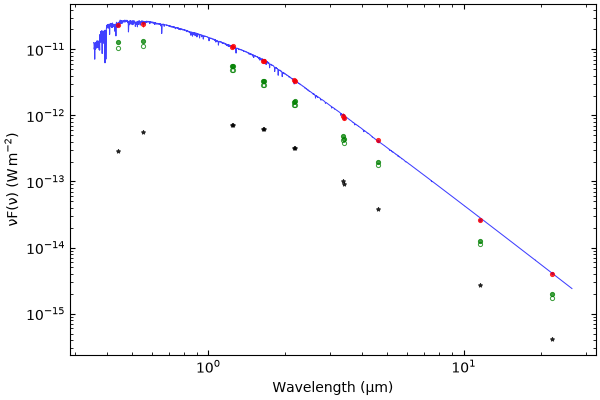

In [89]:
plt.show(plot_fitted_model(sed[retain_mask],
                           theta_min,
                           model_grid,
                           sed_flux_colname="sed_fit_flux",
                           show_component_spectra=False,
                           show_combined_spectrum=True,
                           show_grid=False,
                           show_legend=False))

### MCMC sampling for parameters and uncertainties

In [90]:
thin_by = 10 # sample every nth step from the chain
nwalkers = 100
theta_mcmc, sampler = mcmc_fit(x[retain_mask],
                               y[retain_mask],
                               y_err[retain_mask],
                               theta0=theta0,
                               fit_mask=fit_mask,
                               ln_prior_func=ln_prior_func,
                               stellar_grid=model_grid,
                               nwalkers=nwalkers, nsteps=100000, thin_by=thin_by, processes=8,
                               progress=True, early_stopping=True, early_stopping_from=10000, verbose=True)

mcmc_fit(theta0=[6.406e+03*, 6.406e+03*, 6.406e+03*, 4.263e+00*, 4.289e+00*, 4.500e+00*, 1.389e+00*, 1.318e+00*, 8.000e-01*, 7.768e+01*, 6.200e-03*])
Running MCMC fit on 8 process(es) with 100 walkers for 100000 steps, sampling every 10 steps.
Early stopping will be considered after 10000 steps.


 25%|██▌       | 25000/100000 [40:50<2:02:30, 10.20it/s]


Halting MCMC sampling after 25000 steps as the walkers are beyond 100 times the autocorrelation time & the fit has converged.
Mean Acceptance fraction:    0.385
Autocorrelation steps (tau): 158.168, 167.920, 170.387, 127.659, 132.402, 128.478, 142.199, 138.938, 142.746, 133.728, 133.302
Estimated burn-in steps:     350
Leaving samples of shape:    (246500, 11) *flattened
The MCMC fit yielded theta:  [(6.587+/-0.131)e+03*, (6.470+/-0.158)e+03*, (4.599+/-0.536)e+03*, (4.263+/-0.007)e+00*, (4.289+/-0.009)e+00*, (4.468+/-0.420)e+00*, (1.389+/-0.011)e+00*, (1.318+/-0.014)e+00*, (7.712+/-0.783)e-01*, (7.767+/-0.031)e+01*, (6.035+/-6.149)e-03*]


In [91]:
print(f"Parameters for {target_config['target']} with nominals & 1-sigma uncertainties from MCMC.",
      "\nThose marked * were free. The values in brackets are from the input config.")
for (param, unit), val, fitted in zip(theta_keys, theta_mcmc, fit_mask):
    known = target_config.get(param, np.NaN) if param in target_config else None
    print(f"{param:>12s}{'*' if fitted else ' '} = {val:12.6f} {unit:unicode}",
            f"\t ({known:.6f} {unit:unicode})" if known is not None else "")

Parameters for V455 Aur with nominals & 1-sigma uncertainties from MCMC. 
Those marked * were free. The values in brackets are from the input config.
       TeffA* =  6587.289158+/-  130.649242 K 	 (6500.000000+/-200.000000 K)
       TeffB* =  6470.146432+/-  157.550467 K 	 (6400.000000+/-200.000000 K)
       TeffC* =  4599.138511+/-  536.457708 K 	 (4500.000000+/-500.000000 K)
       loggA* =     4.262620+/-    0.006970 dex 	 (4.262600+/-0.007000 dex)
       loggB* =     4.288669+/-    0.008851 dex 	 (4.288700+/-0.008900 dex)
       loggC* =     4.468304+/-    0.419859 dex 	 (4.500000+/-0.100000 dex)
          RA* =     1.389202+/-    0.010759 R☉ 	 (1.389000+/-0.011000 R☉)
          RB* =     1.318383+/-    0.013642 R☉ 	 (1.318000+/-0.014000 R☉)
          RC* =     0.771208+/-    0.078304 R☉ 	 (0.800000+/-0.200000 R☉)
        dist* =    77.668814+/-    0.306301 pc 	 (77.676730+/-0.312111 pc)
          Av* =     0.006035+/-    0.006149  	 (0.006200+/-0.006200 )


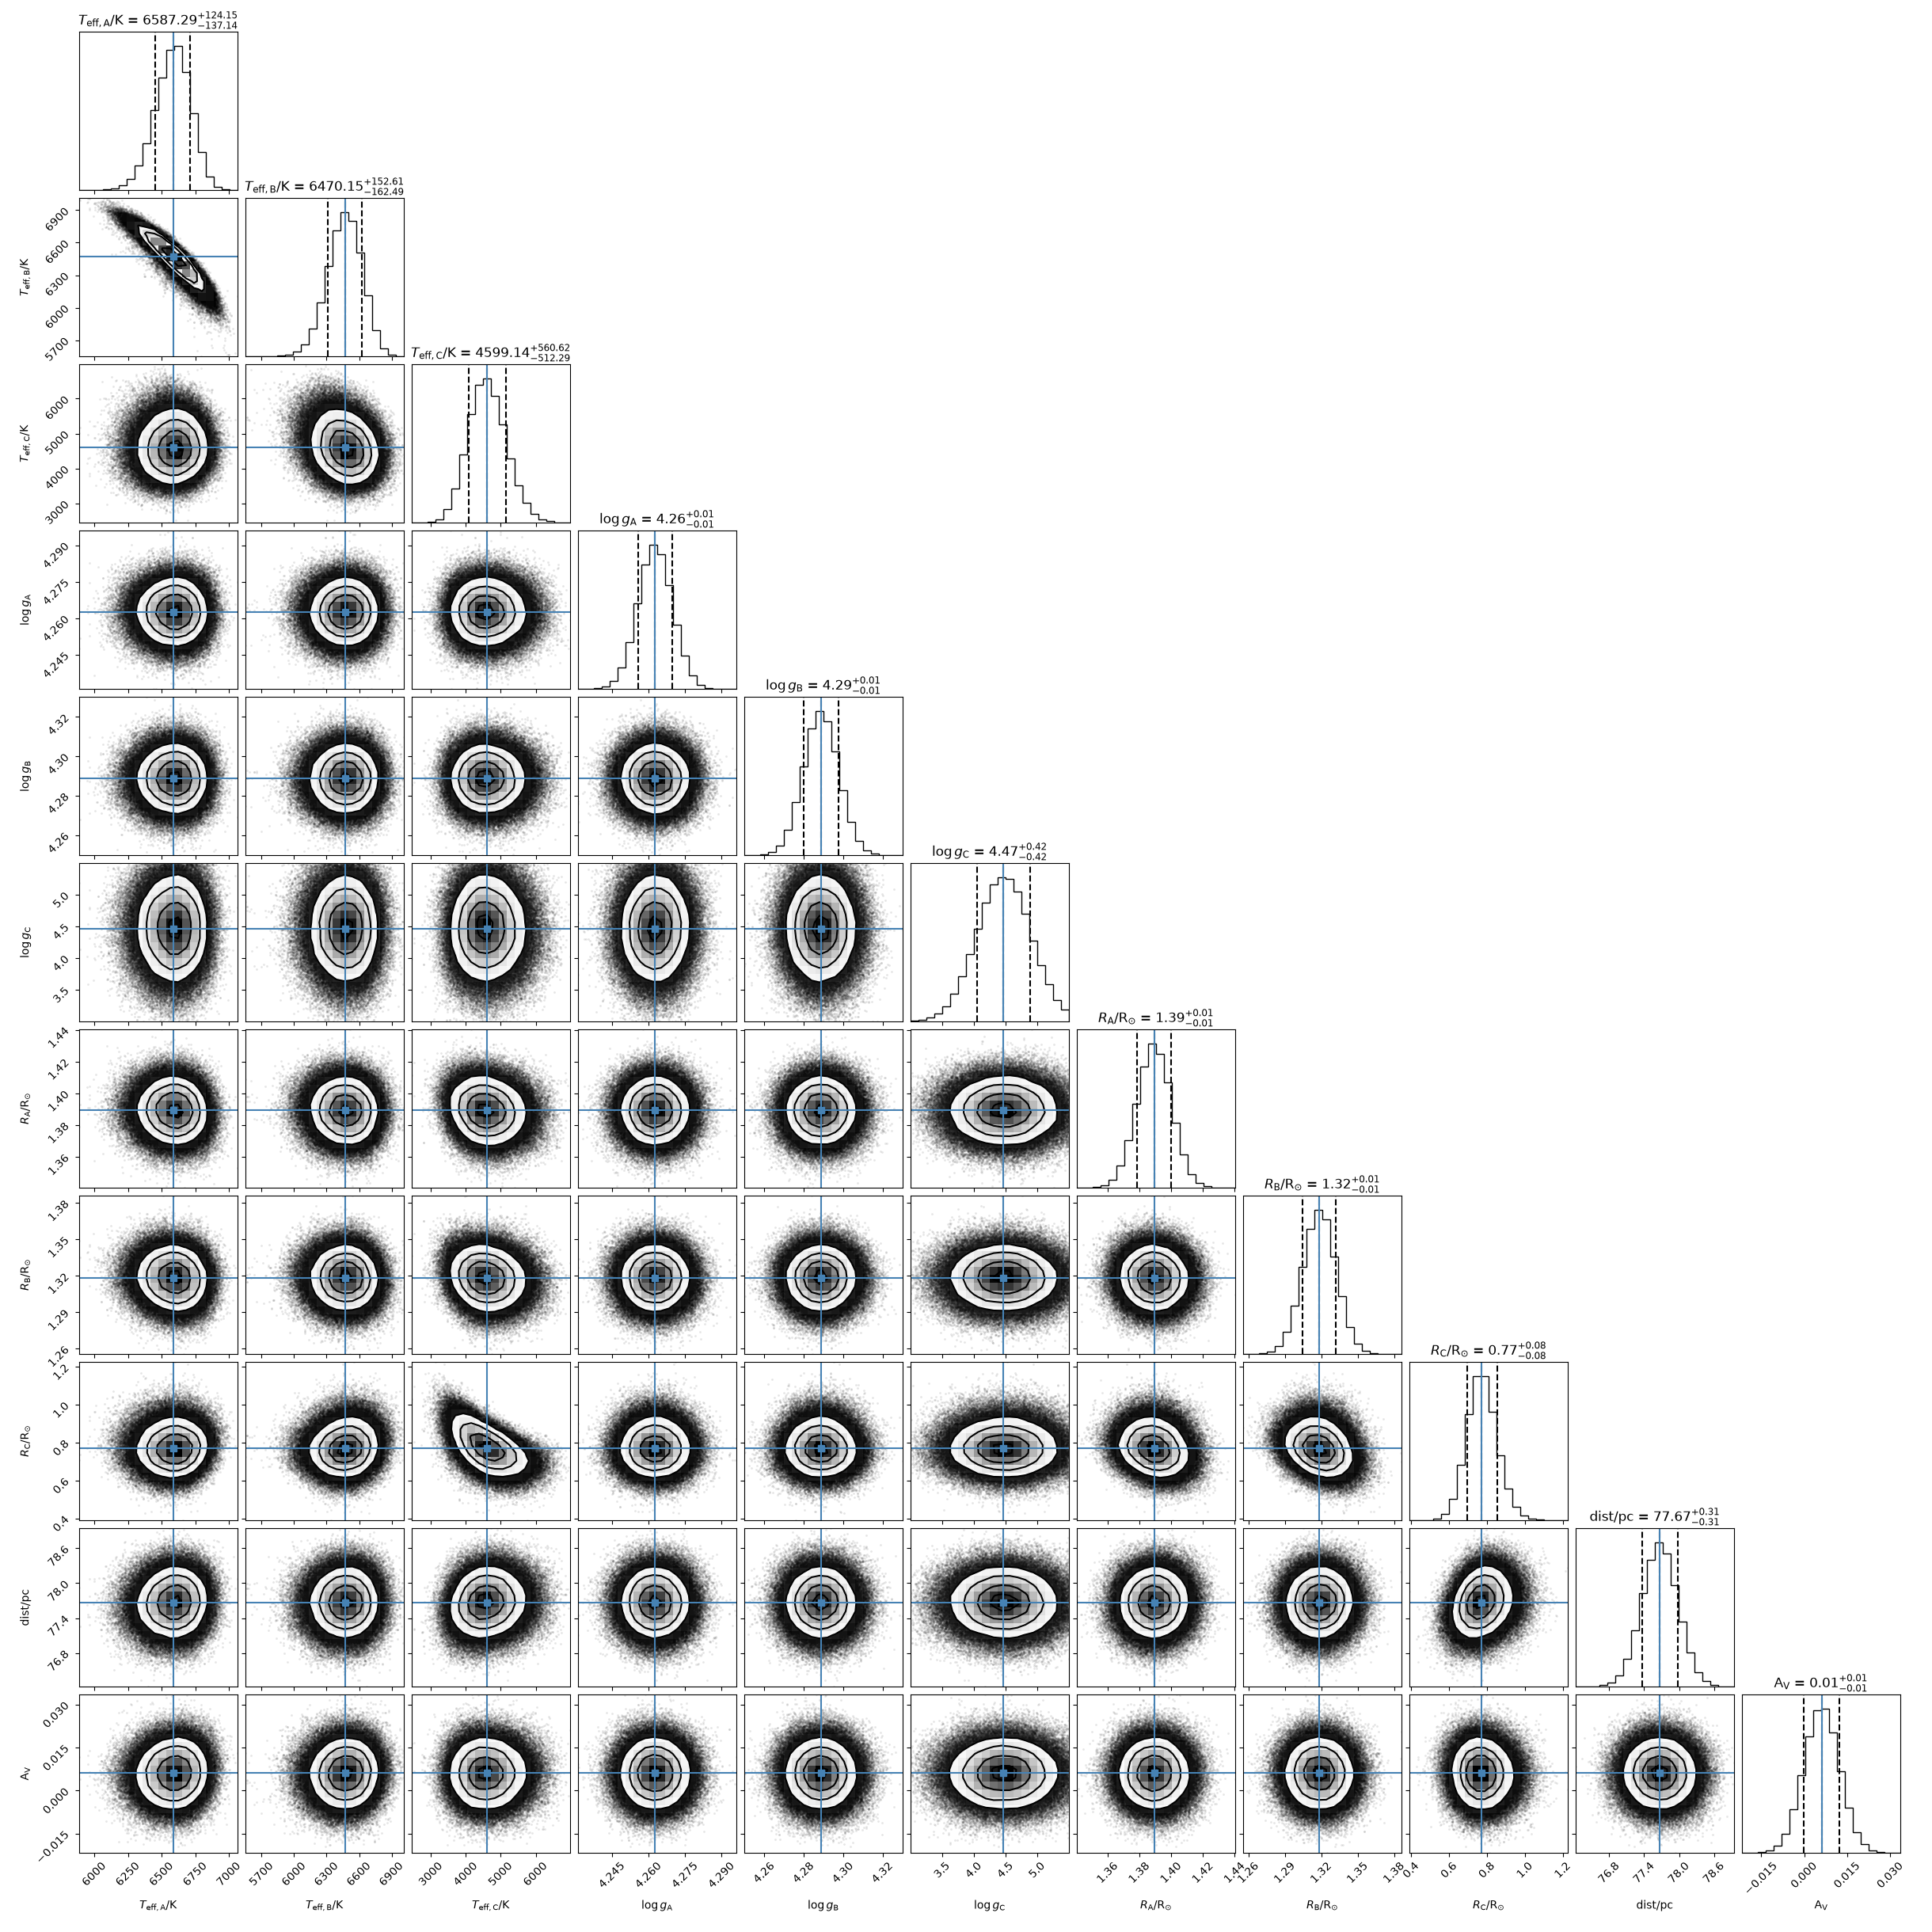

In [92]:
post_burn_samples = samples_from_sampler(sampler, thin_by=thin_by, flat=True)
plt.show(corner.corner(post_burn_samples, show_titles=True, plot_datapoints=True,
                       quantiles=[0.16, 0.5, 0.84], labels=theta_plot_labels[fit_mask],
                       truths=nom_vals(theta_mcmc[fit_mask])))

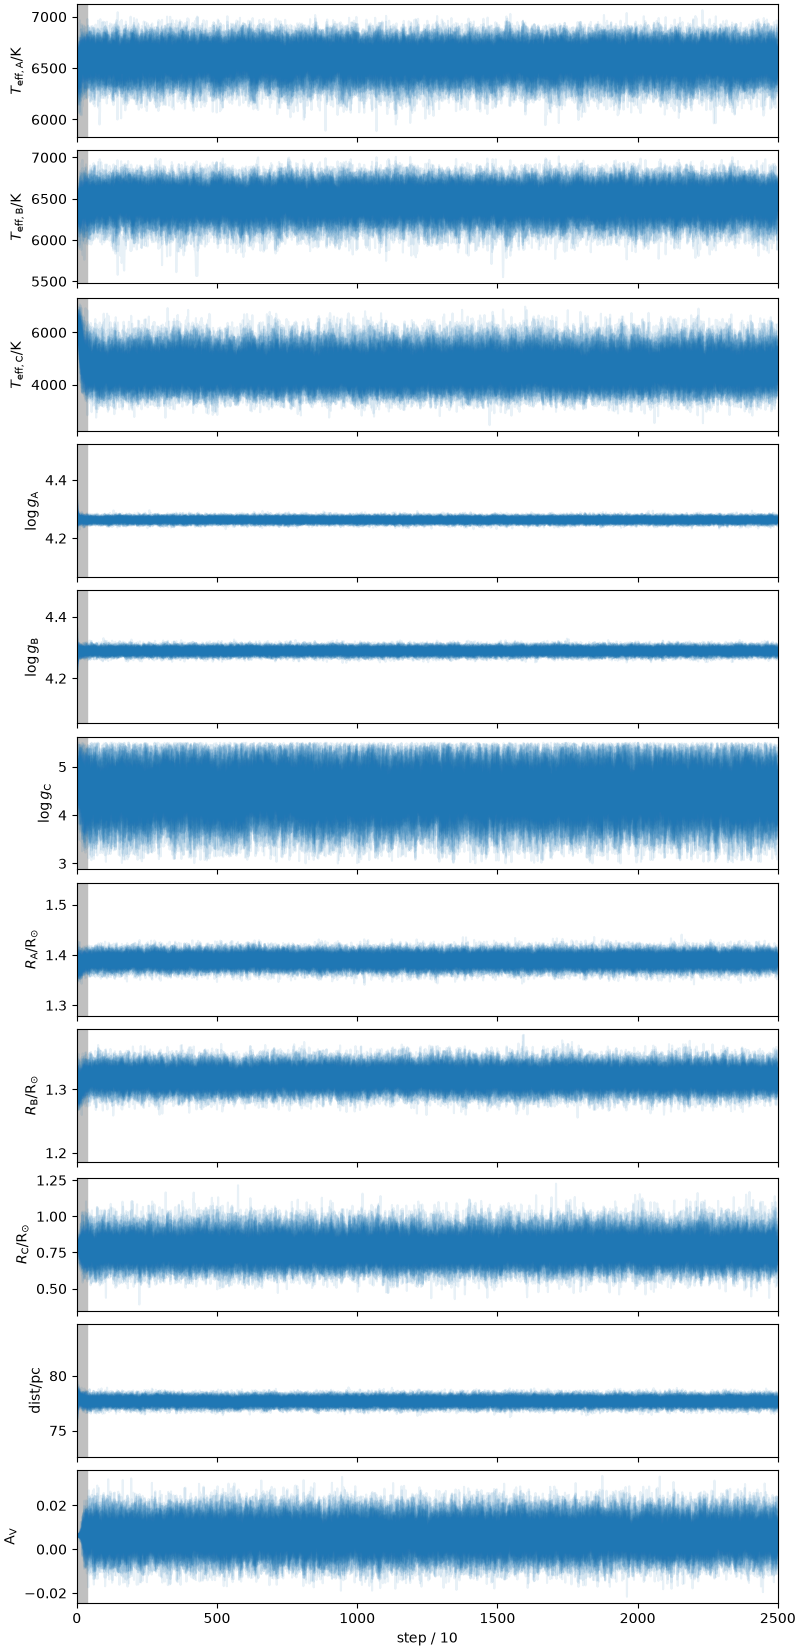

In [94]:
all_samples = sampler.get_chain()
burn_in_samples = all_samples.shape[0] - (post_burn_samples.shape[0] / nwalkers)
fig, axes = plt.subplots(nrows=sum(fit_mask), figsize=(8, 1.5*sum(fit_mask)),
                         sharex=True, constrained_layout=True)
for ix, ax in enumerate(axes.flat):
    ax.plot(all_samples[:, :, ix], "tab:blue", alpha=0.1)
    ax.axvspan(0, burn_in_samples, color="silver")
    ax.set(xlim=(0, len(all_samples)), ylabel=theta_plot_labels[fit_mask][ix])
axes[-1].set(xlabel=f"step / {thin_by}")
plt.show(fig)

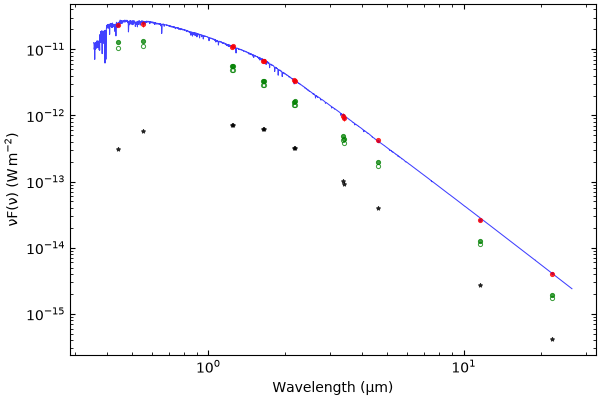

In [95]:
drop_dir = Path("./drop")
drop_dir.mkdir(parents=True, exist_ok=True)

fig = plot_fitted_model(sed[retain_mask], theta_mcmc, model_grid, sed_flux_colname="sed_fit_flux",
                           show_component_spectra=False, show_combined_spectrum=True,
                           show_grid=False, show_legend=False)
fig.savefig(drop_dir / "cw-cma-fitted-sed.pdf", dpi=300)
plt.show(fig)

### Distance calculations
With Kervella+ (2004A&A...426..297K) surface brightness relations

In [98]:
# 2MASS for J, H & K @ JD 2450925.4899 +/- 30 s.
# Quick calculation puts this at approx. phase 0.412 so we will assume outside eclipse.
obs_time_2mass = target_config["mags"]["obs_time_2mass"]
obs_time_2mass_tdb = obs_time_2mass.tdb + obs_time_2mass.light_travel_time(coords)
t0 = Time(nom_val(target_config["t0"]), format="jd", scale="tdb")
phase = (t0 - obs_time_2mass_tdb).to(u.d).value / nom_val(target_config["period"])
phase -= np.floor(phase)
print(f"2MASS J, H & K observations were made at approximate orbital phase {phase:.3f}")

teffs = theta_mcmc[0:NUM_STARS * 1]
radii = theta_mcmc[NUM_STARS*2:NUM_STARS*3]
dist =  theta_mcmc[-2]
av =  theta_mcmc[-1]
av.tag = "AV"
ebv = av / 3.1

# These don't naturally support uncertainties UFloats. Instead we calculate uncertainties
# by perturbing the args over the uncertainty range much as the original absdim code does.
wrapped_deredden = wrap_func_for_uncertainties(deredden)
wrapped_kerv = wrap_func_for_uncertainties(dist_by_brightness_and_teff)
for band in ["B", "V", "J", "H", "K"]:
    mag = target_config["mags"][band]
    dmag = wrapped_deredden(ebv=ebv, mag=mag, band=band)

    dist = wrapped_kerv(Teff1=teffs[0], Teff2=teffs[1], R1=radii[0], R2=radii[1], band=band, mag=dmag)
    print(f"dist[mag({band})={mag:.3f}] = {dist:.6f} pc", end="   ")
    print("\t( err contribs:",
          ", ".join(f"{v.tag}={e/dist.s:.3f}" for v, e in dist.error_components().items()), ")")
    
print(f"\ndist[Gaia DR3 parallax] = {target_config['dist']:.6f} pc\t( RUWE={target_config['ruwe']:.3f} )")

2MASS J, H & K observations were made at approximate orbital phase 0.847
dist[mag(B)=7.710+/-0.010] = 79.034105+/-3.639439 pc   	( err contribs: mag(B)=0.100, AV=0.083, AV=0.101, R1=0.093, Teff2=0.700, Teff1=0.689 )
dist[mag(V)=7.230+/-0.010] = 78.467557+/-2.826762 pc   	( err contribs: mag(V)=0.128, AV=0.081, AV=0.130, R1=0.117, Teff2=0.702, Teff1=0.674 )
dist[mag(J)=6.353+/-0.019] = 73.821263+/-1.419056 pc   	( err contribs: mag(J)=0.455, AV=0.048, AV=0.250, R1=0.216, Teff2=0.606, Teff1=0.560 )
dist[mag(H)=6.132+/-0.038] = 75.432141+/-1.627920 pc   	( err contribs: mag(H)=0.811, AV=0.025, AV=0.224, R1=0.191, Teff2=0.375, Teff1=0.339 )
dist[mag(K)=6.082+/-0.024] = 74.643860+/-1.191315 pc   	( err contribs: mag(K)=0.693, AV=0.029, AV=0.304, R1=0.258, Teff2=0.445, Teff1=0.403 )

dist[Gaia DR3 parallax] = 77.676730+/-0.312111 pc	( RUWE=2.336 )
